# Multimodal Revenue Forecasting

**Project:** Financial Planning & Analysis Intelligence Platform

**Notebook:** `12-multimodal-revenue-forecasting.ipynb`

In [7]:
# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install xgboost
# !pip install matplotlib

In [8]:
# ==========================================
# Notebook 12
# Multimodal Revenue Forecasting
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor

In [9]:
forecast_df = pd.read_csv("../data/multimodal_forecasting_dataset.csv")

forecast_df.head()

,gross_margin_pct,operating_income_million,net_income_million,eps,weighted_sentiment,guidance_score,positive_guidance_score,total_risk_score,normalized_risk_score,macro_risk_score,revenue_million
0,58,22,16,1.20,0.956167,1,1,2,1.0,0.583904,120
1,60,25,18,1.35,0.957692,1,2,1,0.5,0.624035,128
2,61,28,21,1.52,0.951876,2,0,1,0.5,0.565232,138
3,63,32,24,1.72,0.956653,1,1,0,0.0,0.499716,150
4,62,34,26,1.85,0.922371,1,0,0,0.0,0.381064,158


In [10]:
print("Rows:", len(forecast_df))

print("Columns:", len(forecast_df.columns))

forecast_df.columns

Rows: 12
Columns: 11


Index(['gross_margin_pct', 'operating_income_million', 'net_income_million',
       'eps', 'weighted_sentiment', 'guidance_score',
       'positive_guidance_score', 'total_risk_score', 'normalized_risk_score',
       'macro_risk_score', 'revenue_million'],
      dtype='object')

In [11]:
target_column = "revenue_million"

In [12]:
baseline_features = [
    "gross_margin_pct",
    "operating_income_million",
    "net_income_million",
    "eps",
]

In [13]:
multimodal_features = [
    "gross_margin_pct",
    "operating_income_million",
    "net_income_million",
    "eps",
    "weighted_sentiment",
    "guidance_score",
    "positive_guidance_score",
    "total_risk_score",
    "normalized_risk_score",
    "macro_risk_score",
]

In [14]:
X_baseline = forecast_df[baseline_features]

y = forecast_df[target_column]

In [15]:
X_multimodal = forecast_df[multimodal_features]

In [16]:
print("Baseline Shape:", X_baseline.shape)

print("Multimodal Shape:", X_multimodal.shape)

Baseline Shape: (12, 4)
Multimodal Shape: (12, 10)


In [17]:
X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.25, random_state=42
)

In [18]:
X_multi_train, X_multi_test, _, _ = train_test_split(
    X_multimodal, y, test_size=0.25, random_state=42
)

In [19]:
baseline_model = LinearRegression()

baseline_model.fit(X_base_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ -1.43, 1.94, 5.83,-64.13]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['gross_margin_pct','operating_income_million','net_income_million','eps']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,147.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [20]:
baseline_predictions = baseline_model.predict(X_base_test)

In [21]:
baseline_predictions

array([220.75932978, 208.9946687 , 123.13404417])

In [22]:
baseline_mae = mean_absolute_error(y_test, baseline_predictions)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))

baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline MAE:", round(baseline_mae, 4))

print("Baseline RMSE:", round(baseline_rmse, 4))

print("Baseline R2:", round(baseline_r2, 4))

Baseline MAE: 1.7933
Baseline RMSE: 2.0308
Baseline R2: 0.998


In [23]:
multimodal_model = XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
)

In [24]:
multimodal_model.fit(X_multi_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [25]:
multimodal_predictions = multimodal_model.predict(X_multi_test)

In [26]:
multimodal_mae = mean_absolute_error(y_test, multimodal_predictions)

multimodal_rmse = np.sqrt(mean_squared_error(y_test, multimodal_predictions))

multimodal_r2 = r2_score(y_test, multimodal_predictions)

print("Multimodal MAE:", round(multimodal_mae, 4))

print("Multimodal RMSE:", round(multimodal_rmse, 4))

print("Multimodal R2:", round(multimodal_r2, 4))

Multimodal MAE: 6.7571
Multimodal RMSE: 6.855
Multimodal R2: 0.9773


In [27]:
comparison_df = pd.DataFrame(
    {
        "Model": ["Baseline", "Multimodal"],
        "MAE": [baseline_mae, multimodal_mae],
        "RMSE": [baseline_rmse, multimodal_rmse],
        "R2": [baseline_r2, multimodal_r2],
    }
)

comparison_df

,Model,MAE,RMSE,R2
0,Baseline,1.793349,2.030779,0.998010
1,Multimodal,6.757105,6.855008,0.977321


In [28]:
results_df = pd.DataFrame(
    {
        "Actual Revenue": y_test.values,
        "Baseline Prediction": baseline_predictions,
        "Multimodal Prediction": multimodal_predictions,
    }
)

results_df

,Actual Revenue,Baseline Prediction,Multimodal Prediction
0,222,220.759330,215.471451
1,210,208.994669,215.471451
2,120,123.134044,128.271317


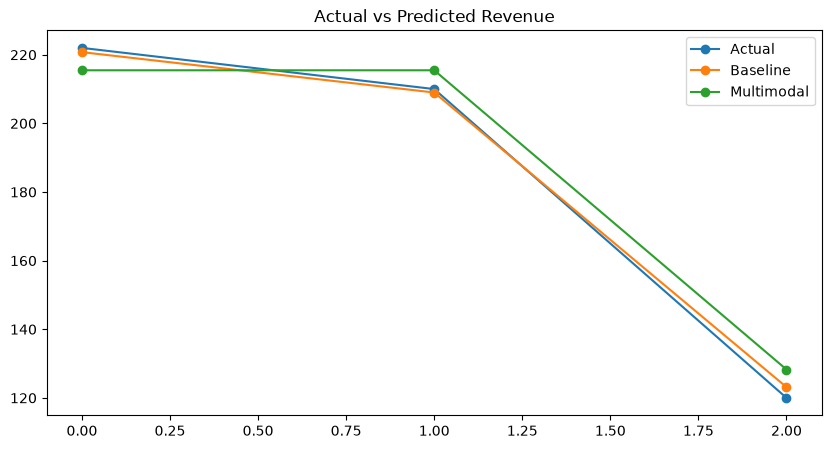

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(results_df["Actual Revenue"].values, marker="o", label="Actual")

plt.plot(results_df["Baseline Prediction"].values, marker="o", label="Baseline")

plt.plot(results_df["Multimodal Prediction"].values, marker="o", label="Multimodal")

plt.legend()

plt.title("Actual vs Predicted Revenue")

plt.show()

In [30]:
importance_df = pd.DataFrame(
    {
        "feature": multimodal_features,
        "importance": multimodal_model.feature_importances_,
    }
)

In [31]:
importance_df = importance_df.sort_values(by="importance", ascending=False)

importance_df

,feature,importance
1,operating_income_million,0.919092
0,gross_margin_pct,0.080908
2,net_income_million,0.000000
3,eps,0.000000
4,weighted_sentiment,0.000000
5,guidance_score,0.000000
6,positive_guidance_score,0.000000
7,total_risk_score,0.000000
8,normalized_risk_score,0.000000
9,macro_risk_score,0.000000


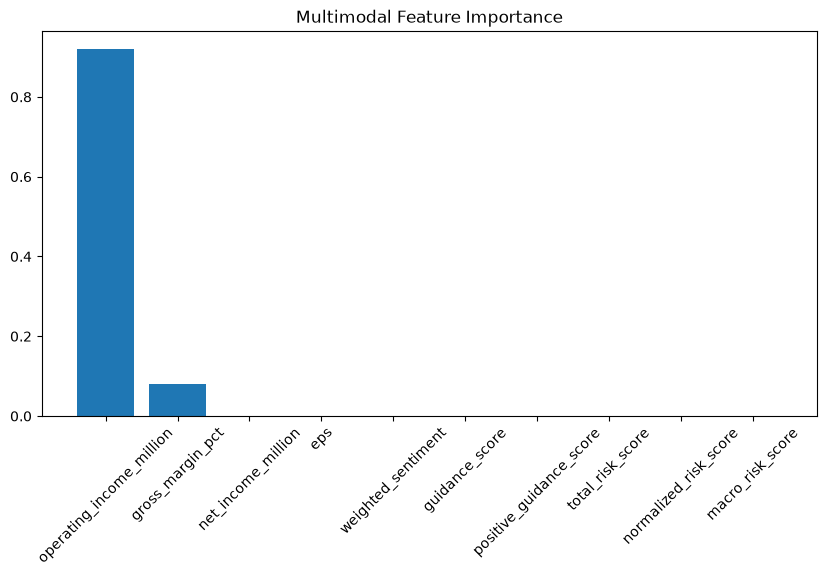

In [32]:
plt.figure(figsize=(10, 5))

plt.bar(importance_df["feature"], importance_df["importance"])

plt.xticks(rotation=45)

plt.title("Multimodal Feature Importance")

plt.show()

In [33]:
importance_df.head(5)

,feature,importance
1,operating_income_million,0.919092
0,gross_margin_pct,0.080908
2,net_income_million,0.000000
3,eps,0.000000
4,weighted_sentiment,0.000000


In [34]:
future_quarter = pd.DataFrame(
    {
        "gross_margin_pct": [65],
        "operating_income_million": [36],
        "net_income_million": [28],
        "eps": [2.0],
        "weighted_sentiment": [0.92],
        "guidance_score": [4],
        "positive_guidance_score": [3],
        "total_risk_score": [1],
        "normalized_risk_score": [0.25],
        "macro_risk_score": [0.35],
    }
)

In [35]:
future_prediction = multimodal_model.predict(future_quarter)

future_prediction

array([167.01021], dtype=float32)

In [36]:
mae_improvement = baseline_mae - multimodal_mae

rmse_improvement = baseline_rmse - multimodal_rmse

print("MAE Improvement:", round(mae_improvement, 4))

print("RMSE Improvement:", round(rmse_improvement, 4))

MAE Improvement: -4.9638
RMSE Improvement: -4.8242


In [37]:
comparison_df.to_csv("../data/multimodal_model_comparison.csv", index=False)

In [38]:
results_df.to_csv("../data/multimodal_predictions.csv", index=False)

In [39]:
importance_df.to_csv("../data/multimodal_feature_importance.csv", index=False)